In [7]:
from lifelines.datasets import load_gbsg2
import pandas as pd
import matplotlib.pyplot as plt

df = load_gbsg2()
display(df)

df.to_csv("../data/gbsg2.csv", index = False)

,horTh,age,menostat,tsize,tgrade,pnodes,progrec,estrec,time,cens
0,no,70,Post,21,II,3,48,66,1814,1
1,yes,56,Post,12,II,7,61,77,2018,1
2,yes,58,Post,35,II,9,52,271,712,1
3,yes,59,Post,17,II,4,60,29,1807,1
4,no,73,Post,35,II,1,26,65,772,1
...,...,...,...,...,...,...,...,...,...,...
681,no,49,Pre,30,III,3,1,84,721,0
682,yes,53,Post,25,III,17,0,0,186,0
683,no,51,Pre,25,III,5,43,0,769,1
684,no,52,Post,23,II,3,15,34,727,1


Loads dataset GBSG2 (German Breast Cancer Study Group)

Columns: hormonal therapy, age, menopausal status, tumour size, tumour grade, no. of + lymph nodes, progesterone level, estrogen level, time and censor

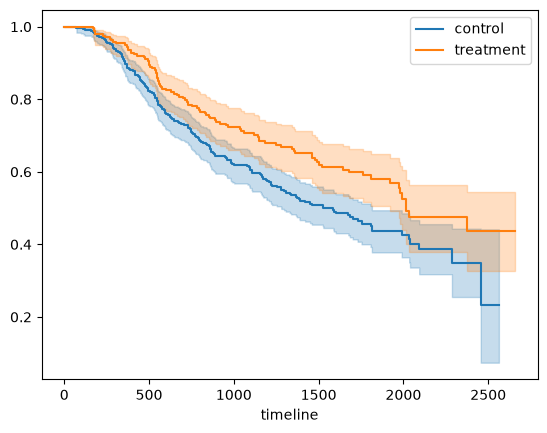

In [11]:
Time = df["time"]
Cens = df["cens"]

from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()

group_1 = df["horTh"]
x = (group_1 == "yes")

kmf.fit(Time[~x], Cens[~x], label = "control")
axis = kmf.plot_survival_function()
kmf.fit(Time[x], Cens[x], label = "treatment")
axis = kmf.plot_survival_function(ax = axis)

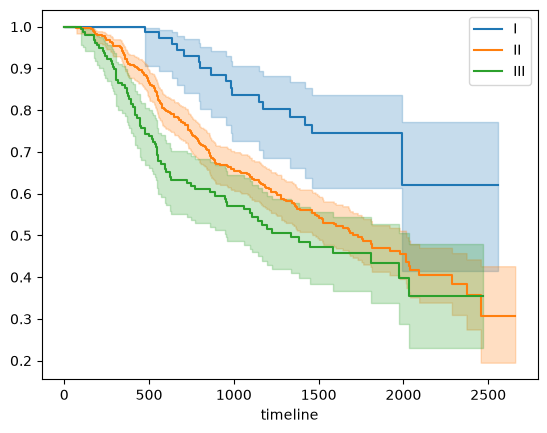

In [12]:
axis = plt.subplot(111)

for tgrade, grouped_df in df.groupby("tgrade"):
    kmf.fit(grouped_df["time"], grouped_df["cens"], label = tgrade)
    kmf.plot_survival_function(ax=axis)